# Evaluasi Keterbatasan YOLO pada Deteksi Objek Kecil Berkelompok: Pengaruh Resolusi Input 640×640 vs 1280×1280 pada VisDrone2019-DET


### ROYAN ADITYA | **Topik:** Opsi C — YOLO
**Paper:** J. Redmon et al., *You Only Look Once*, CVPR 2016 (Bagian 2.4, Limitations of YOLO)
**Tautan Colab:** https://colab.research.google.com/drive/1TnAlv6CbAk7BmOWFfBnA2fgfowAaRCaE (akses "Anyone with the link can view")

### Klaim paper yang diuji
Redmon et al. (2016) melaporkan bahwa YOLO memiliki keterbatasan dalam mendeteksi objek kecil yang berkelompok karena representasi berbasis grid dan keterbatasan jumlah prediksi pada setiap sel. Eksperimen ini menguji apakah fenomena tersebut masih terlihat pada YOLO modern dan apakah peningkatan resolusi input dapat mengurangi masalah tersebut.

### Pertanyaan riset
1. **RQ1.** Apakah fenomena kesulitan deteksi objek kecil yang dilaporkan pada YOLOv1 masih terlihat pada YOLO11n ketika diuji pada VisDrone2019-DET, berdasarkan AP untuk objek small, medium, dan large?
2. **RQ2.** Apakah menaikkan resolusi input 640 -> 1280 memperbaiki AP objek kecil, dan berapa biaya komputasinya?

### Kondisi eksperimen
| Kondisi | Model | Resolusi latih dan uji | Peran |
|---|---|---|---|
| A | YOLO11n (pretrained COCO) | 640x640 | Baseline |
| B | YOLO11n (pretrained COCO) | 1280x1280 | Intervensi |

Semua hiperparameter identik, termasuk jumlah epoch (tanpa early stopping). Hanya resolusi input yang berbeda.

### Data
VisDrone2019-DET (Tianjin University). Latih: sub-sampel acak (seed 42) dari 6.471 citra karena batas waktu Colab. Validasi: 548 citra (val). Uji: 1.610 citra (test-dev), tidak dipakai saat pelatihan.

### Peta notebook terhadap laporan
1-2 -> Setup eksperimen | 3 -> Metode | 4-5 -> Hasil | 6 -> Analisis | 7 -> Kesimpulan dan keterbatasan

### Checklist sebelum dikumpulkan
- [ ] Runtime -> Run all tanpa error (GPU T4 atau lebih baik). Data diunduh otomatis (sekitar 2,3 GB dari GitHub Releases Ultralytics)
- [ ] Simpan notebook DENGAN output
- [ ] Semua tabel dan gambar laporan diambil dari /content/results
- [ ] Akses tautan Colab sudah "Anyone with the link can view"

# 1. Setup dan reproduktibilitas

In [ ]:
!pip -q install ultralytics pycocotools

In [ ]:
import os, io, sys, json, glob, time, random, shutil, zipfile, platform, subprocess, contextlib, urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import cv2
import torch
from PIL import Image
from IPython.display import display

import ultralytics
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ---------------- Seed ----------------
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
set_seed(SEED)

# ---------------- Konfigurasi (satu-satunya tempat mengubah parameter) ----------------
MODEL_WEIGHTS      = "yolo11n.pt"
IMGSZ_BASELINE     = 640     # Kondisi A
IMGSZ_INTERVENTION = 1280    # Kondisi B
EPOCHS             = 30
PATIENCE           = 1000   # early stopping dibuat tidak aktif secara praktis agar kedua kondisi menjalani epoch yang sama
BATCH_SIZE         = 2
TRAIN_SUBSET       = 2000   # jumlah citra latih (sub-sampel seed tetap); None = semua 6.471
MAX_DET            = 500    # maksimum deteksi per citra (evaluasi dan prediksi)
AR_KEY             = f"AR@{MAX_DET}"
FORCE_RETRAIN      = False

CONF_EVAL  = 0.001   # ambang rendah untuk AP
IOU_NMS    = 0.7
CONF_VIS   = 0.25    # ambang untuk recall dan kasus gagal
IOU_MATCH  = 0.5

# Ukuran objek seperti COCO (piksel citra asli)
AREA_RANGES = {"all": [0, 1e10], "small": [0, 32**2], "medium": [32**2, 96**2], "large": [96**2, 1e10]}
def size_bucket(area):
    return "Small" if area < 32**2 else ("Medium" if area < 96**2 else "Large")
BUCKETS = ["Small", "Medium", "Large"]

OUT_DIR     = "/content/experiments"
RESULTS_DIR = Path("/content/results")
FIG_DIR     = RESULTS_DIR / "figures"
for d in (OUT_DIR, RESULTS_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option("display.width", 160)

def save_json(obj, name):
    with open(RESULTS_DIR / name, "w") as f:
        json.dump(obj, f, indent=2, default=float)

print("Seed:", SEED)
print(f"Model: {MODEL_WEIGHTS} | A={IMGSZ_BASELINE} vs B={IMGSZ_INTERVENTION} | epochs={EPOCHS}, patience={PATIENCE}, batch={BATCH_SIZE}")

Seed: 42
Model: yolo11n.pt | A=640 vs B=1280 | epochs=30, patience=1000, batch=2


In [ ]:
env_info = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "ultralytics": ultralytics.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "gpu_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if torch.cuda.is_available() else None,
}
display(pd.Series(env_info, name="value").to_frame())
save_json(env_info, "environment.json")
if not torch.cuda.is_available():
    print("PERINGATAN: GPU tidak aktif. Runtime -> Change runtime type -> GPU.")

,value
python,3.13.15
torch,2.11.0+cu128
ultralytics,8.4.166
cuda_available,True
gpu,Tesla T4
gpu_memory_gb,15.6000


# 2. Dataset dan analisis ukuran objek
**Dataset:** VisDrone2019-DET (Du et al., Tianjin University), citra udara dari drone dengan 10 kelas: `pedestrian, people, bicycle, car, van, truck, tricycle, awning-tricycle, bus, motor`. Dataset ini dipilih karena disarankan lembar tugas untuk Opsi C dan berisi banyak objek kecil yang berkelompok.

## 2.1 Unduh dan siapkan data otomatis
Tiga berkas ZIP (train, val, test-dev) diunduh dari GitHub Releases Ultralytics, lalu anotasi VisDrone diubah ke format YOLO. Baris anotasi dengan skor 0 (*ignored regions* dan kategori *others*) dibuang. Citra latih di-sub-sampel dengan seed tetap. Sel ini aman dijalankan ulang: ZIP yang sudah ada tidak diunduh lagi.

In [ ]:
ASSETS_URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0"
VISDRONE_ZIPS = {"train": "VisDrone2019-DET-train.zip", "valid": "VisDrone2019-DET-val.zip", "test": "VisDrone2019-DET-test-dev.zip"}
CLASS_NAMES = ["pedestrian", "people", "bicycle", "car", "van", "truck", "tricycle", "awning-tricycle", "bus", "motor"]

RAW_ROOT    = "/content/visdrone_raw"
DATASET_DIR = "/content/visdrone_yolo"

def download_file(url, dest, retries=3):
    if os.path.exists(dest) and os.path.getsize(dest) > 0:
        print("sudah ada:", dest); return
    for k in range(retries):
        try:
            urllib.request.urlretrieve(url, dest + ".part")
            os.rename(dest + ".part", dest)
            return
        except Exception as e:
            print(f"unduhan gagal ({k + 1}/{retries}): {e}")
            time.sleep(3)
    raise RuntimeError(f"Gagal mengunduh {url}")

def visdrone_to_yolo_line(row, W, H):
    # baris VisDrone: x, y, w, h, score, kategori, terpotong, terhalang
    x, y, w, h = map(float, row[:4]); score = int(float(row[4])); cat = int(float(row[5]))
    if score == 0 or not (1 <= cat <= 10):     # ignored regions (0) dan others (11)
        return None
    x1, y1, x2, y2 = max(x, 0), max(y, 0), min(x + w, W), min(y + h, H)
    if x2 - x1 < 1 or y2 - y1 < 1:
        return None
    return f"{cat - 1} {(x1 + x2) / 2 / W:.6f} {(y1 + y2) / 2 / H:.6f} {(x2 - x1) / W:.6f} {(y2 - y1) / H:.6f}"

os.makedirs(RAW_ROOT, exist_ok=True)
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

conv_stats = {}
for split, zname in VISDRONE_ZIPS.items():
    zpath = os.path.join(RAW_ROOT, zname)
    download_file(f"{ASSETS_URL}/{zname}", zpath)
    raw_dir = os.path.join(RAW_ROOT, zname[:-4])
    if not os.path.isdir(os.path.join(raw_dir, "images")):
        with zipfile.ZipFile(zpath) as z:
            z.extractall(RAW_ROOT)
    raw_imgs = sorted(f for f in os.listdir(os.path.join(raw_dir, "images")) if f.lower().endswith(".jpg"))
    if split == "train" and TRAIN_SUBSET is not None and TRAIN_SUBSET < len(raw_imgs):
        raw_imgs = sorted(random.Random(SEED).sample(raw_imgs, TRAIN_SUBSET))
    out_img = os.path.join(DATASET_DIR, split, "images"); out_lbl = os.path.join(DATASET_DIR, split, "labels")
    os.makedirs(out_img); os.makedirs(out_lbl)
    n_obj = n_drop = 0
    for fn in raw_imgs:
        shutil.copy2(os.path.join(raw_dir, "images", fn), os.path.join(out_img, fn))
        with Image.open(os.path.join(out_img, fn)) as im:
            W, H = im.size
        lines = []
        ann = os.path.join(raw_dir, "annotations", os.path.splitext(fn)[0] + ".txt")
        if os.path.exists(ann):
            for raw_line in open(ann):
                row = raw_line.strip().split(",")
                if len(row) < 6:
                    continue
                out = visdrone_to_yolo_line(row, W, H)
                if out is None:
                    n_drop += 1
                else:
                    lines.append(out); n_obj += 1
        with open(os.path.join(out_lbl, os.path.splitext(fn)[0] + ".txt"), "w") as f:
            f.write("\n".join(lines))
    conv_stats[split] = {"citra": len(raw_imgs), "objek_valid": n_obj, "baris_dibuang": n_drop}

display(pd.DataFrame(conv_stats).T)

SPLIT_DIRS = {"train": "train", "valid": "valid", "test": "test"}
SPLITS = {s: (os.path.join(DATASET_DIR, s, "images"), os.path.join(DATASET_DIR, s, "labels")) for s in SPLIT_DIRS}
TEST_IMG_DIR, TEST_LABEL_DIR = SPLITS["test"]

DATA_YAML = os.path.join(DATASET_DIR, "data.yaml")
with open(DATA_YAML, "w") as f:
    yaml.safe_dump({"path": DATASET_DIR, "train": "train/images", "val": "valid/images", "test": "test/images",
                    "names": {i: n for i, n in enumerate(CLASS_NAMES)}}, f)
print("Dataset dir :", DATASET_DIR)
print("Kelas       :", CLASS_NAMES)
print("data.yaml   :", DATA_YAML)

sudah ada: /content/visdrone_raw/VisDrone2019-DET-train.zip
sudah ada: /content/visdrone_raw/VisDrone2019-DET-val.zip
sudah ada: /content/visdrone_raw/VisDrone2019-DET-test-dev.zip


,citra,objek_valid,baris_dibuang
train,2000,105879,3243
valid,548,38759,1410
test,1610,75102,2445


Dataset dir : /content/visdrone_yolo
Kelas       : ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
data.yaml   : /content/visdrone_yolo/data.yaml


In [ ]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def list_images(folder):
    return sorted(os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS))

def label_path_for(img_path, label_dir):
    return os.path.join(label_dir, os.path.splitext(os.path.basename(img_path))[0] + ".txt")

def read_yolo_labels(path):
    """Baca label YOLO (cls xc yc w h). Baris bukan 5 kolom diabaikan dan dihitung."""
    rows, bad = [], 0
    if not os.path.exists(path):
        return rows, bad
    with open(path) as f:
        for line in f:
            p = line.split()
            if not p:
                continue
            if len(p) != 5:
                bad += 1
                continue
            rows.append((int(float(p[0])), *map(float, p[1:])))
    return rows, bad

EXPECTED_COUNTS = {"train": TRAIN_SUBSET if TRAIN_SUBSET else 6471, "valid": 548, "test": 1610}
rows = []
for split, (img_dir, lbl_dir) in SPLITS.items():
    imgs = list_images(img_dir)
    n_lbl_files = len([f for f in os.listdir(lbl_dir) if f.endswith(".txt")])
    no_label = sum(not os.path.exists(label_path_for(p, lbl_dir)) for p in imgs)
    bad = sum(read_yolo_labels(label_path_for(p, lbl_dir))[1] for p in imgs)
    rows.append({"split": split, "images": len(imgs), "label_files": n_lbl_files,
                 "images_tanpa_label": no_label, "baris_label_tidak_valid": bad})
    if split in EXPECTED_COUNTS and len(imgs) != EXPECTED_COUNTS[split]:
        print(f"PERINGATAN: split {split} berisi {len(imgs)} citra, diharapkan {EXPECTED_COUNTS[split]}.")
split_summary = pd.DataFrame(rows).set_index("split")
display(split_summary)
split_summary.to_csv(RESULTS_DIR / "dataset_split_summary.csv")

,images,label_files,images_tanpa_label,baris_label_tidak_valid
split,,,,
train,2000,2000,0,0
valid,548,548,0,0
test,1610,1610,0,0


## 2.2 Distribusi kelas dan ukuran objek
Ukuran seperti COCO: small < 32², medium 32²-96², large > 96² piksel. Distribusi ini menentukan apakah pertanyaan tentang objek kecil dapat dijawab pada dataset ini.

Jumlah bounding box: 219740

Ukuran citra per split (W,H): jumlah
  train  {(1400, 1050): 792, (1400, 788): 398, (2000, 1500): 227, (1360, 765): 224, (1916, 1078): 156}
  valid  {(1360, 765): 408, (960, 540): 121, (1920, 1080): 19}
  test   {(1400, 788): 933, (1400, 1050): 274, (1360, 765): 167, (1916, 1078): 151, (960, 540): 49}

Jumlah anotasi per kelas dan split:


split,train,valid,test
class_name,,,
awning-tricycle,1003,532,599
bicycle,3386,1287,1302
bus,1851,251,2940
car,45699,14064,28074
motor,9026,4886,5845
pedestrian,23374,8844,21006
people,8352,5125,6376
tricycle,1536,1045,530
truck,4093,750,2659


Ukuran objek per split:


size,Small,Medium,Large
split,,,
train,63778,36027,6074
valid,26586,11105,1068
test,50837,21856,2409


Persentase per split (%):


size,Small,Medium,Large
split,,,
train,60.2400,34.0300,5.7400
valid,68.5900,28.6500,2.7600
test,67.6900,29.1000,3.2100


Ukuran objek per kelas:


size,Small,Medium,Large
class_name,,,
awning-tricycle,1008,1052,74
bicycle,4433,1493,49
bus,1304,2837,901
car,43775,38302,5760
motor,15622,4036,99
pedestrian,46092,6926,206
people,17918,1894,41
tricycle,1608,1415,88
truck,2354,3931,1217


Statistik luas kotak (piksel^2) per kelas:


,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
awning-tricycle,2134.0000,2246.3021,4521.1783,20.0010,485.9935,1119.0110,2402.2656,77584.8358
bicycle,5975.0000,996.8989,1857.5440,10.0000,230.9937,511.9920,1051.5001,36243.8895
bus,5042.0000,6553.3224,14891.1093,12.0023,987.2316,2686.9829,6789.7318,324299.8568
car,87837.0000,2815.0552,5941.4145,2.9990,378.0083,1029.0043,2886.0033,355432.3531
motor,19757.0000,810.1595,1564.5970,6.0005,199.9934,433.9919,895.9768,64680.1155
pedestrian,53224.0000,592.6974,1340.7053,6.0016,96.0050,239.9998,571.9764,58134.7874
people,19853.0000,461.7438,941.2752,6.0002,96.0058,220.0005,494.0068,33783.8970
tricycle,3111.0000,1997.3741,3537.6989,7.9983,437.0123,972.0065,2206.5063,78768.8865
truck,7502.0000,6214.3059,14381.7926,12.0023,779.9806,2160.0104,6215.7665,317260.4484


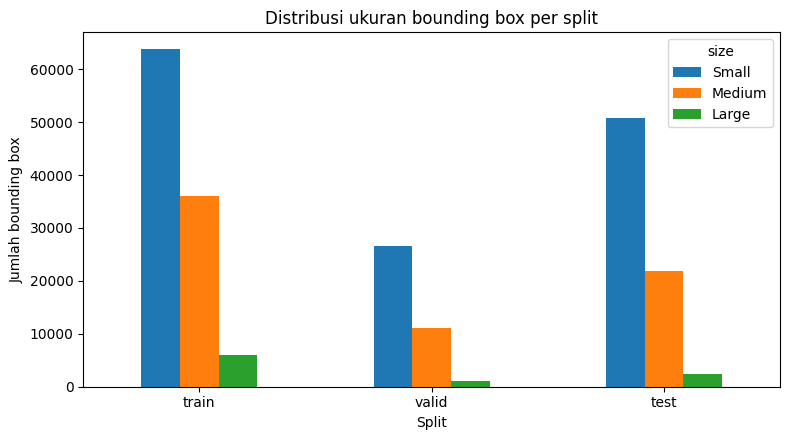

In [ ]:
bbox_records, image_sizes = [], {}
for split, (img_dir, lbl_dir) in SPLITS.items():
    sizes = Counter()
    for p in list_images(img_dir):
        with Image.open(p) as im:
            W, H = im.size
        sizes[(W, H)] += 1
        labels, _ = read_yolo_labels(label_path_for(p, lbl_dir))
        for cls, xc, yc, bw, bh in labels:
            w, h = bw * W, bh * H
            bbox_records.append({"split": split, "image": os.path.basename(p), "class_id": cls, "class_name": CLASS_NAMES[cls],
                                 "img_w": W, "img_h": H, "bbox_w": w, "bbox_h": h, "bbox_area": w * h,
                                 "area_frac": (w * h) / (W * H), "size": size_bucket(w * h)})
    image_sizes[split] = sizes

bbox_df = pd.DataFrame(bbox_records)
print("Jumlah bounding box:", len(bbox_df))

print("\nUkuran citra per split (W,H): jumlah")
for s, c in image_sizes.items():
    print(f"  {s:6s}", dict(c.most_common(5)))

max_side = max(max(k) for c in image_sizes.values() for k in c)
if max_side <= 640:
    print(f"\nPERINGATAN: sisi terpanjang citra asli = {max_side}px. Input 1280 hanya meng-upsample citra "
          "sehingga tidak menambah detail baru. Bahas di analisis dan keterbatasan.")

class_dist = pd.crosstab(bbox_df["class_name"], bbox_df["split"]).reindex(columns=list(SPLITS), fill_value=0)
print("\nJumlah anotasi per kelas dan split:")
display(class_dist)

size_by_split = pd.crosstab(bbox_df["split"], bbox_df["size"]).reindex(index=list(SPLITS), columns=BUCKETS, fill_value=0)
size_by_class = pd.crosstab(bbox_df["class_name"], bbox_df["size"]).reindex(columns=BUCKETS, fill_value=0)
print("Ukuran objek per split:");  display(size_by_split)
print("Persentase per split (%):"); display((size_by_split.div(size_by_split.sum(axis=1), axis=0) * 100).round(2))
print("Ukuran objek per kelas:");  display(size_by_class)
print("Statistik luas kotak (piksel^2) per kelas:")
display(bbox_df.groupby("class_name")["bbox_area"].describe())

class_dist.to_csv(RESULTS_DIR / "class_distribution.csv")
size_by_split.to_csv(RESULTS_DIR / "size_distribution_by_split.csv")
size_by_class.to_csv(RESULTS_DIR / "size_distribution_by_class.csv")

ax = size_by_split.plot(kind="bar", figsize=(8, 4.5))
ax.set_title("Distribusi ukuran bounding box per split")
ax.set_xlabel("Split"); ax.set_ylabel("Jumlah bounding box"); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(FIG_DIR / "size_distribution.png", dpi=200); plt.show()

n_small_test = int(size_by_split.loc["test", "Small"])
if n_small_test < 30:
    print(f"\nPERINGATAN: hanya {n_small_test} objek Small di test set. AP small akan sangat tidak stabil. "
          "Cantumkan sebagai keterbatasan.")

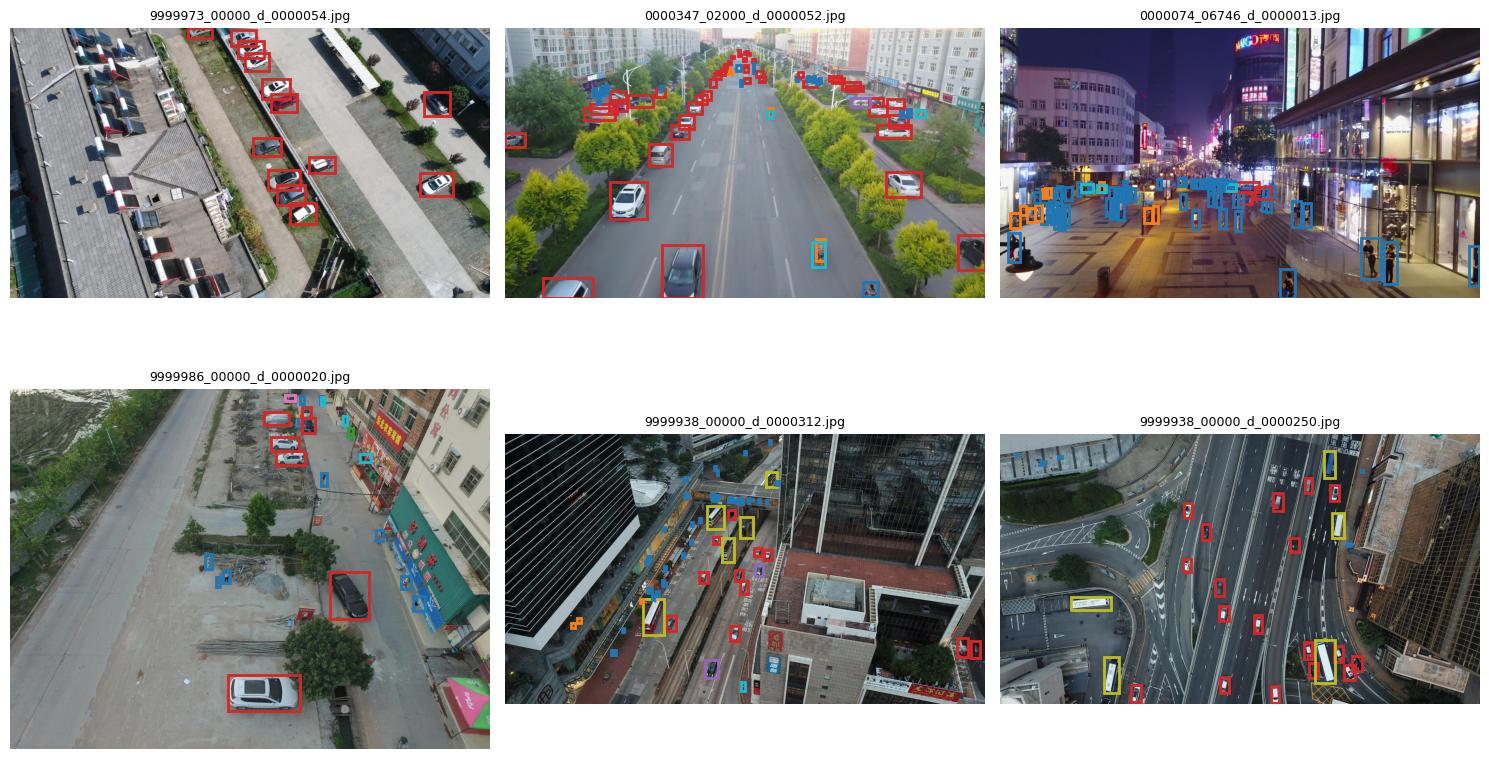

In [ ]:
rng = random.Random(SEED)
test_imgs = list_images(TEST_IMG_DIR)
sample = rng.sample(test_imgs, min(6, len(test_imgs)))
palette = plt.cm.tab10(np.arange(10))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, p in zip(axes.flat, sample):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)
    for cls, xc, yc, bw, bh in read_yolo_labels(label_path_for(p, TEST_LABEL_DIR))[0]:
        x1, y1 = (xc - bw / 2) * W, (yc - bh / 2) * H
        ax.add_patch(plt.Rectangle((x1, y1), bw * W, bh * H, fill=False, lw=2, color=palette[cls % 10]))
        pass
    ax.set_title(os.path.basename(p)[:40], fontsize=9); ax.axis("off")
for ax in list(axes.flat)[len(sample):]:
    ax.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "annotation_examples.png", dpi=200); plt.show()

# 3. Ringkasan metode

**YOLOv1 (Redmon et al., 2016).** Citra dibagi grid SxS. Tiap sel memprediksi B kotak (x, y, w, h, confidence) dan satu set probabilitas kelas, dalam satu forward pass. Bagian 2.4 menyebut tiga keterbatasan: (i) tiap sel hanya memprediksi sedikit kotak dan satu kelas, sehingga objek kecil berkelompok sulit dideteksi; (ii) generalisasi ke rasio aspek tak lazim lemah; (iii) loss memperlakukan galat kotak besar dan kecil sama.

**Yang diimplementasikan.** Bukan re-implementasi YOLOv1, melainkan pengujian klaim keterbatasannya pada detektor satu tahap modern.

| Aspek | Paper (YOLOv1) | Eksperimen ini (YOLO11n) | Alasan |
|---|---|---|---|
| Arsitektur | Grid 7x7, 2 kotak/sel | Multi-skala (P3-P5), anchor-free | Menguji apakah keterbatasan masih berlaku pada YOLO modern |
| Resolusi | 448x448 | 640 vs 1280 | Intervensi yang diminta penugasan |
| Data | PASCAL VOC | VisDrone2019-DET | Objek kecil berkelompok, disarankan lembar tugas |
| Metrik | mAP@0,5 (VOC) | mAP@0,5 dan @0,5:0,95 per ukuran | Metrik wajib Opsi C |
| Bobot awal | ImageNet | COCO (yolo11n.pt) | Data latih sub-sampel |

**AP per ukuran (COCO).** Untuk rentang luas [a_min, a_max], GT di luar rentang diabaikan, dan deteksi tak cocok yang luasnya di luar rentang juga diabaikan. AP = rata-rata presisi terinterpolasi 101 titik recall atas kelas. mAP@0,5:0,95 dirata-ratakan atas IoU 0,50 sampai 0,95.

**Catatan.** Angka paper (mAP VOC) tidak dapat dibandingkan langsung. Yang dibandingkan adalah tren kualitatif: apakah objek kecil tetap paling lemah.

## 3.1 Formulasi YOLOv1 (Redmon et al., 2016, Bag. 2.1-2.2)
Citra dibagi grid $S \times S$. **Sel yang memuat titik pusat objek bertanggung jawab** atas objek itu. Setiap sel memprediksi $B$ kotak $(x, y, w, h, \text{confidence})$ dan $C$ probabilitas kelas, sehingga keluaran berukuran $S \times S \times (5B + C)$. Pada eksperimen ini $C = 10$ (kelas VisDrone).

Fungsi loss YOLOv1:

$$
\begin{aligned}
\mathcal{L} = \;& \lambda_\text{coord} \sum_{i} \mathbb{1}_i^\text{obj} \big[(x_i-\hat x_i)^2 + (y_i-\hat y_i)^2\big]
+ \lambda_\text{coord} \sum_{i} \mathbb{1}_i^\text{obj} \Big[\big(\sqrt{w_i}-\sqrt{\hat w_i}\big)^2 + \big(\sqrt{h_i}-\sqrt{\hat h_i}\big)^2\Big] \\\\
&+ \sum_{i} \mathbb{1}_i^\text{obj} (C_i-\hat C_i)^2 + \lambda_\text{noobj} \sum_{i} \mathbb{1}_i^\text{noobj} (C_i-\hat C_i)^2
+ \sum_{i} \mathbb{1}_i^\text{obj} \sum_{c} \big(p_i(c)-\hat p_i(c)\big)^2
\end{aligned}
$$

dengan $\lambda_\text{coord}=5$ dan $\lambda_\text{noobj}=0{,}5$. Akar pada $w, h$ dipakai agar galat pada kotak kecil lebih terasa (keterbatasan ke-3 di Bag. 2.4 menyebut loss tetap memperlakukan galat kotak besar dan kecil relatif sama).

**Keterbatasan struktural (Bag. 2.4).** Karena satu sel hanya bertanggung jawab atas satu objek (dalam `encode_yolov1_target` di bawah: objek kedua pada sel yang sama dibuang), YOLOv1 dengan $S=7$ hanya dapat merepresentasikan maksimal $S^2 = 49$ objek per citra, dan objek kecil yang berdekatan bisa saling menghapus. Fungsi-fungsi di bawah diadaptasi dari notebook tutorial Sesi 3 (kerangka awal yang diizinkan penugasan), lalu dipakai untuk mengukur seberapa sering hal itu terjadi pada data VisDrone.

In [ ]:
# Diadaptasi dari notebook tutorial Sesi 3 (encode target dan loss YOLOv1). Ditambah penghitung objek yang terbuang.
def encode_yolov1_target(boxes_xyxy, classes, W, H, S=7, C=2):
    T = np.zeros((S, S, 5 + C), np.float32)
    dropped = 0
    for (x1, y1, x2, y2), c in zip(boxes_xyxy, classes):
        cx, cy = (x1 + x2) / 2 / W, (y1 + y2) / 2 / H
        bw, bh = (x2 - x1) / W, (y2 - y1) / H
        col, row = min(int(cx * S), S - 1), min(int(cy * S), S - 1)
        if T[row, col, 4] == 1:      # sel sudah dipakai objek lain -> objek ini hilang
            dropped += 1
            continue
        T[row, col, :5] = [cx * S - col, cy * S - row, bw, bh, 1.0]
        T[row, col, 5 + c] = 1.0
    return T, dropped

def yolov1_loss(pred, target, l_coord=5.0, l_noobj=0.5):
    obj = target[..., 4] == 1
    noobj = ~obj
    xy = np.sum((target[obj, 0:2] - pred[obj, 0:2]) ** 2)
    wh = np.sum((np.sqrt(target[obj, 2:4]) - np.sqrt(pred[obj, 2:4])) ** 2)
    conf_obj = np.sum((target[obj, 4] - pred[obj, 4]) ** 2)
    conf_noobj = np.sum((target[noobj, 4] - pred[noobj, 4]) ** 2)
    cls = np.sum((target[obj, 5:] - pred[obj, 5:]) ** 2)
    return {"coord_xy": l_coord * xy, "coord_wh": l_coord * wh, "conf_obj": conf_obj,
            "conf_noobj": l_noobj * conf_noobj, "class": cls,
            "total": l_coord * (xy + wh) + conf_obj + l_noobj * conf_noobj + cls}

# Demo pada satu citra latih VisDrone: prediksi acak vs prediksi mendekati target
demo_img = next(p for p in list_images(SPLITS["train"][0]) if read_yolo_labels(label_path_for(p, SPLITS["train"][1]))[0])
with Image.open(demo_img) as im:
    Wd, Hd = im.size
lab = read_yolo_labels(label_path_for(demo_img, SPLITS["train"][1]))[0]
boxes_d = [((xc - bw / 2) * Wd, (yc - bh / 2) * Hd, (xc + bw / 2) * Wd, (yc + bh / 2) * Hd) for _, xc, yc, bw, bh in lab]
T_d, _ = encode_yolov1_target(boxes_d, [c for c, *_ in lab], Wd, Hd, S=7, C=len(CLASS_NAMES))
rng_d = np.random.default_rng(SEED)
pred_random = rng_d.uniform(0, 1, T_d.shape).astype(np.float32)
pred_near = np.clip(T_d + np.concatenate([rng_d.normal(0, 0.02, T_d[..., :4].shape), np.zeros(T_d[..., 4:].shape)], -1), 0, 1).astype(np.float32)
print("Citra demo:", os.path.basename(demo_img), "| objek:", len(lab))
print("Prediksi acak  :", {k: round(float(v), 3) for k, v in yolov1_loss(pred_random, T_d).items()})
print("Prediksi dekat :", {k: round(float(v), 3) for k, v in yolov1_loss(pred_near, T_d).items()})

Citra demo: 0000007_04999_d_0000036.jpg | objek: 57
Prediksi acak  : {'coord_xy': 40.531, 'coord_wh': 22.051, 'conf_obj': 6.015, 'conf_noobj': 4.31, 'class': 58.682, 'total': 131.589}
Prediksi dekat : {'coord_xy': 0.056, 'coord_wh': 0.138, 'conf_obj': 0.0, 'conf_noobj': 0.0, 'class': 0.0, 'total': 0.194}


## 3.2 Seberapa "berkelompok" objek pada dataset ini?
Klaim yang diuji menyangkut objek kecil yang **berkelompok**. Di sini diukur berapa persen ground truth yang akan **terbuang** bila anotasi dikodekan dengan aturan YOLOv1 (satu objek per sel) pada beberapa ukuran grid. $S=7$ adalah YOLOv1; $S=80$ dan $S=160$ kira-kira setara peta fitur P3 (stride 8) YOLO11 pada input 640 dan 1280. Semakin besar persentasenya, semakin berkelompok datanya.

In [ ]:
GRID_SIZES = [7, 20, 40, 80, 160]
rows_g = []
for S_ in GRID_SIZES:
    for split, (img_dir, lbl_dir) in SPLITS.items():
        tot = drop = 0
        for p in list_images(img_dir):
            seen = set()
            for cls, xc, yc, bw, bh in read_yolo_labels(label_path_for(p, lbl_dir))[0]:
                cell = (min(int(xc * S_), S_ - 1), min(int(yc * S_), S_ - 1))
                tot += 1
                if cell in seen:
                    drop += 1
                seen.add(cell)
        rows_g.append({"S": S_, "split": split, "n_gt": tot, "gt_terbuang": drop, "terbuang_%": 100 * drop / max(tot, 1)})
grid_df = pd.DataFrame(rows_g)
grid_pivot = grid_df.pivot(index="S", columns="split", values="terbuang_%")[list(SPLITS)]
print("Persentase GT terbuang (satu objek per sel):")
display(grid_pivot)
grid_df.to_csv(RESULTS_DIR / "grid_collision.csv", index=False)

per_img = bbox_df.groupby(["split", "image"]).size().rename("objek_per_citra").reset_index()
dens = per_img.groupby("split")["objek_per_citra"].agg(["count", "mean", "max"])
dens.columns = ["citra_berobjek", "rata2_objek_per_citra", "maks_objek_per_citra"]
print("Kepadatan objek per citra:")
display(dens.loc[list(SPLITS)])
dens.to_csv(RESULTS_DIR / "objects_per_image.csv")

Persentase GT terbuang (satu objek per sel):


split,train,valid,test
S,,,
7,70.2500,74.0499,66.4882
20,38.8415,40.2539,35.3479
40,20.4299,20.3772,18.7478
80,8.1404,7.7556,8.1050
160,2.4226,1.9583,2.4367


Kepadatan objek per citra:


,citra_berobjek,rata2_objek_per_citra,maks_objek_per_citra
split,,,
train,2000,52.9395,370
valid,548,70.7281,317
test,1610,46.6472,461


# 4. Pelatihan dan evaluasi standar
Kedua kondisi memakai fungsi pelatihan yang sama, sehingga satu-satunya perbedaan adalah `imgsz`. Bobot terbaik diambil dari `save_dir` yang dilaporkan Ultralytics.

In [ ]:
def train_model(run_name, imgsz):
    """Latih YOLO11n dengan konfigurasi identik; hanya imgsz yang berbeda."""
    info_path = RESULTS_DIR / f"train_info_{run_name}.json"
    if info_path.exists() and not FORCE_RETRAIN:
        info = json.load(open(info_path))
        if Path(info["best"]).exists():
            print(f"[{run_name}] memakai hasil latih sebelumnya: {info['best']}")
            return info
    set_seed(SEED)
    model = YOLO(MODEL_WEIGHTS)
    t0 = time.time()
    model.train(data=DATA_YAML, epochs=EPOCHS, imgsz=imgsz, batch=BATCH_SIZE, seed=SEED, deterministic=True,
                patience=PATIENCE, project=OUT_DIR, name=run_name, exist_ok=True, save=True, val=True, plots=True)
    minutes = (time.time() - t0) / 60
    save_dir = Path(model.trainer.save_dir)
    log = pd.read_csv(save_dir / "results.csv")
    log.columns = [c.strip() for c in log.columns]
    info = {"run": run_name, "imgsz": imgsz, "best": str(save_dir / "weights" / "best.pt"), "save_dir": str(save_dir),
            "train_minutes": round(minutes, 2), "epochs_run": int(len(log)),
            "best_epoch": int(log["metrics/mAP50-95(B)"].idxmax()) + 1,
            "best_val_map50_95": float(log["metrics/mAP50-95(B)"].max())}
    save_json(info, f"train_info_{run_name}.json")
    return info

train_A = train_model("yolo11n_640", IMGSZ_BASELINE)
print(train_A)

[yolo11n_640] memakai hasil latih sebelumnya: /content/experiments/yolo11n_640/weights/best.pt
{'run': 'yolo11n_640', 'imgsz': 640, 'best': '/content/experiments/yolo11n_640/weights/best.pt', 'save_dir': '/content/experiments/yolo11n_640', 'train_minutes': 27.32, 'epochs_run': 30, 'best_epoch': 30, 'best_val_map50_95': 0.12419}


In [ ]:
train_B = train_model("yolo11n_1280", IMGSZ_INTERVENTION)
print(train_B)

[yolo11n_1280] memakai hasil latih sebelumnya: /content/experiments/yolo11n_1280/weights/best.pt
{'run': 'yolo11n_1280', 'imgsz': 1280, 'best': '/content/experiments/yolo11n_1280/weights/best.pt', 'save_dir': '/content/experiments/yolo11n_1280', 'train_minutes': 60.88, 'epochs_run': 30, 'best_epoch': 30, 'best_val_map50_95': 0.22605}


In [ ]:
# ============================================================
# CELL 19 — ULTRALYTICS TEST EVALUATION
# ============================================================

import gc
import torch
import pandas as pd
from ultralytics import YOLO


def ultra_eval(best_path, imgsz, tag):

    # Batch kecil untuk menghemat RAM/VRAM
    eval_batch = 1

    m = YOLO(best_path)

    r = m.val(
        data=DATA_YAML,
        split="test",
        imgsz=imgsz,
        batch=eval_batch,
        conf=CONF_EVAL,
        iou=IOU_NMS,
        max_det=MAX_DET,

        # Tidak membuat plot tambahan
        plots=False,

        project=OUT_DIR,
        name=f"test_{tag}",
        exist_ok=True,
        verbose=False
    )

    # Total waktu per image
    total_ms = float(sum(r.speed.values()))

    # AP50 setiap kelas
    per_class = {
        CLASS_NAMES[int(i)]: float(a)
        for i, a in zip(
            r.box.ap_class_index,
            r.box.ap50
        )
    }

    result = {
        "imgsz": imgsz,
        "mAP@0.5": float(r.box.map50),
        "mAP@0.5:0.95": float(r.box.map),
        "precision": float(r.box.mp),
        "recall": float(r.box.mr),
        "inference_ms": float(r.speed["inference"]),
        "total_ms_per_img": total_ms,
        "fps": 1000.0 / total_ms,
        "params_M": sum(
            p.numel()
            for p in m.model.parameters()
        ) / 1e6,
        "per_class_AP50": per_class
    }

    # Bersihkan model dan hasil evaluasi
    del r
    del m

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# ============================================================
# MODEL A
# ============================================================

print("===== Evaluasi Model A =====")

ultra_A = ultra_eval(
    train_A["best"],
    IMGSZ_BASELINE,
    "640"
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# MODEL B
# ============================================================

print("===== Evaluasi Model B =====")

ultra_B = ultra_eval(
    train_B["best"],
    IMGSZ_INTERVENTION,
    "1280"
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# HASIL
# ============================================================

std_df = pd.DataFrame({
    f"A: {IMGSZ_BASELINE}": ultra_A,
    f"B: {IMGSZ_INTERVENTION}": ultra_B
}).drop(
    index="per_class_AP50"
).astype(float)

print("===== Evaluasi test set (Ultralytics) =====")

display(std_df)


print("===== AP@0.5 per kelas =====")

display(
    pd.DataFrame({
        "A": ultra_A["per_class_AP50"],
        "B": ultra_B["per_class_AP50"]
    })
)


# Simpan hasil
std_df.to_csv(
    RESULTS_DIR / "standard_metrics_test.csv"
)

===== Evaluasi Model A =====
Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3447.1±820.6 MB/s, size: 224.9 KB)
val: Scanning /content/visdrone_yolo/test/labels... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 1.6Kit/s 1.0s
val: New cache created: /content/visdrone_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1610/1610 39.3it/s 41.0s
                   all       1610      75102      0.302      0.251        0.2      0.108
Speed: 0.9ms preprocess, 15.0ms inference, 0.0ms loss, 3.0ms postprocess per image
===== Evaluasi Model B =====
Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image acce

,A: 640,B: 1280
imgsz,640.0000,1280.0000
mAP@0.5,0.2001,0.3249
mAP@0.5:0.95,0.1079,0.1869
precision,0.3016,0.4259
recall,0.2510,0.3580
inference_ms,15.0158,18.5460
total_ms_per_img,18.9247,24.8804
fps,52.8409,40.1923
params_M,2.5918,2.5918


===== AP@0.5 per kelas =====


,A,B
pedestrian,0.1575,0.3280
people,0.0634,0.1664
bicycle,0.0341,0.1283
car,0.5964,0.7450
van,0.2287,0.3757
truck,0.2223,0.3646
tricycle,0.0705,0.1447
awning-tricycle,0.0756,0.1443
bus,0.4075,0.5456
motor,0.1449,0.3063


# 5. Evaluasi per ukuran objek (COCO)
Ultralytics tidak memberi AP per ukuran, sehingga dihitung dengan pycocotools. Angka COCO di sini dan angka Ultralytics di bagian 4 dihitung dengan prosedur berbeda (interpolasi, urutan pencocokan, dan cara merata-ratakan kelas), sehingga bisa berselisih. Selisihnya belum tentu kecil, jadi bagian 5.2 menghitung AP@0,5 sekali lagi dengan fungsi eksplisit buatan sendiri dan menampilkan ketiganya berdampingan. Pembandingan A vs B tetap memakai pipeline yang sama pada tiap sumber. Ground truth dibangun sekali dengan `category_id = class_id + 1`.

In [ ]:
def build_coco_gt(img_dir, label_dir, class_names):
    """Bangun COCO GT dari label YOLO. Return (COCO, gt_by_image[path] = [(cls,x1,y1,x2,y2)])."""
    images, anns, gt_by_image, ann_id = [], [], {}, 1
    for image_id, p in enumerate(list_images(img_dir), start=1):
        with Image.open(p) as im:
            W, H = im.size
        images.append({"id": image_id, "file_name": os.path.basename(p), "width": W, "height": H})
        boxes = []
        for cls, xc, yc, bw, bh in read_yolo_labels(label_path_for(p, label_dir))[0]:
            w, h = bw * W, bh * H
            x, y = xc * W - w / 2, yc * H - h / 2
            anns.append({"id": ann_id, "image_id": image_id, "category_id": cls + 1, "bbox": [x, y, w, h],
                         "area": w * h, "iscrowd": 0})
            boxes.append((cls, x, y, x + w, y + h))
            ann_id += 1
        gt_by_image[p] = boxes
    gt = COCO()
    gt.dataset = {"info": {}, "licenses": [], "images": images, "annotations": anns,
                  "categories": [{"id": i + 1, "name": n, "supercategory": "object"} for i, n in enumerate(class_names)]}
    with contextlib.redirect_stdout(io.StringIO()):
        gt.createIndex()
    return gt, gt_by_image

coco_gt, gt_by_image = build_coco_gt(TEST_IMG_DIR, TEST_LABEL_DIR, CLASS_NAMES)
TEST_IMAGES = list_images(TEST_IMG_DIR)
path_to_id = {os.path.join(TEST_IMG_DIR, im["file_name"]): im["id"] for im in coco_gt.dataset["images"]}

gt_areas = np.array([a["area"] for a in coco_gt.dataset["annotations"]])
n_gt = {"all": len(gt_areas), "small": int((gt_areas < 32**2).sum()),
        "medium": int(((gt_areas >= 32**2) & (gt_areas < 96**2)).sum()), "large": int((gt_areas >= 96**2).sum())}
print("Test set: %d citra, %d anotasi" % (len(coco_gt.imgs), len(coco_gt.anns)))
print("Jumlah GT per ukuran:", n_gt)
if n_gt["small"] == 0:
    print("PERINGATAN: tidak ada objek small di test set. AP small akan NaN dan RQ untuk objek kecil "
          "tidak dapat dijawab dengan definisi COCO. Pertimbangkan ambang relatif atau dataset lain.")

Test set: 1610 citra, 75102 anotasi
Jumlah GT per ukuran: {'all': 75102, 'small': 50837, 'medium': 21856, 'large': 2409}


In [ ]:
# ============================================================
# CELL 22 (FIX) — PREDIKSI DI SUBPROCESS, PER-GAMBAR, BISA DILANJUT
# ============================================================
# Kenapa kernel mati sebelumnya:
#   Prediksi 1610 gambar bukan penyebabnya (hasilnya cuma puluhan MB). Yang
#   habis adalah RAM proses kernel Colab yang sudah "gemuk" setelah training,
#   val, dan EDA, lalu ditambah predict(stream=True) atas daftar 1610 path.
# Solusi:
#   - Prediksi jalan di PROSES TERPISAH. Selesai/crash -> RAM dibebaskan OS,
#     kernel notebook tetap hidup.
#   - Satu gambar per panggilan, hasil langsung ke disk (1 file .npz/gambar).
#   - RESUMABLE: kalau proses dimatikan, jalankan sel lagi dan ia melanjutkan.
# ============================================================

import gc, json, subprocess, sys
from pathlib import Path

import numpy as np
import torch

# ---- bebaskan sisa objek dari sel-sel sebelumnya ----
for _v in ("model", "model_test", "results", "r", "m"):
    globals().pop(_v, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

PRED_ROOT = Path(RESULTS_DIR) / "prediction_cache"
PRED_ROOT.mkdir(parents=True, exist_ok=True)


class DiskPredictionStore:
    """Tampilan mirip dict: store[path] -> (xyxy, conf, cls). Data dibaca dari disk."""

    def __init__(self, folder, images):
        self.folder = Path(folder)
        self._index = {str(p): self.folder / f"{Path(p).stem}.npz" for p in images}

    def n_ready(self):
        return sum(f.exists() for f in self._index.values())

    def __getitem__(self, path):
        f = self._index[str(path)]
        with np.load(f) as d:
            return d["xyxy"], d["conf"], d["cls"]

    def __contains__(self, path):
        return str(path) in self._index

    def __len__(self):
        return len(self._index)

    def __iter__(self):
        return iter(self._index)

    def keys(self):
        return self._index.keys()

    def items(self):                       # dipakai average_precision_manual
        for p in self._index:
            yield p, self[p]


WORKER_SRC = r'''
import gc, json, os, sys
from pathlib import Path
import numpy as np
import torch
from ultralytics import YOLO

cfg = json.load(open(sys.argv[1]))
out = Path(cfg["out_dir"]); out.mkdir(parents=True, exist_ok=True)
todo = [p for p in cfg["images"] if not (out / f"{Path(p).stem}.npz").exists()]
print(f"sudah ada: {len(cfg['images']) - len(todo)} | akan diprediksi: {len(todo)}", flush=True)

model = YOLO(cfg["weights"])
try:
    import psutil; proc = psutil.Process(os.getpid())
except Exception:
    proc = None

n_det = 0
for i, p in enumerate(todo, 1):
    with torch.inference_mode():
        r = model.predict(p, imgsz=cfg["imgsz"], conf=cfg["conf"], iou=cfg["iou"],
                          max_det=cfg["max_det"], device=cfg["device"], verbose=False)[0]
    b = r.boxes
    xyxy = b.xyxy.cpu().numpy().astype(np.float32)
    conf = b.conf.cpu().numpy().astype(np.float32)
    cls = b.cls.cpu().numpy().astype(np.int16)
    final = out / f"{Path(p).stem}.npz"
    part = out / f"{Path(p).stem}.part"
    with open(part, "wb") as f:                 # tulis atomik: crash tidak meninggalkan file rusak
        np.savez(f, xyxy=xyxy, conf=conf, cls=cls)
    os.replace(part, final)
    n_det += len(xyxy)
    del r, b, xyxy, conf, cls
    if i % 50 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        ram = f" | RAM proses {proc.memory_info().rss / 1e9:.2f} GB" if proc else ""
        print(f"{i:5d}/{len(todo)} gambar | deteksi {n_det:,}{ram}", flush=True)
print("WORKER SELESAI", flush=True)
'''
Path("/content/predict_worker.py").write_text(WORKER_SRC)


def predict_all_disk(best_path, imgsz, cache_name, max_retry=4):
    folder = PRED_ROOT / cache_name
    store = DiskPredictionStore(folder, TEST_IMAGES)     # TIDAK menghapus cache lama -> resumable
    cfg = {"weights": str(best_path), "imgsz": int(imgsz), "out_dir": str(folder),
           "images": [str(p) for p in TEST_IMAGES], "conf": CONF_EVAL, "iou": IOU_NMS,
           "max_det": MAX_DET, "device": 0 if torch.cuda.is_available() else "cpu"}
    cfg_path = PRED_ROOT / f"{cache_name}_cfg.json"
    cfg_path.write_text(json.dumps(cfg))

    print("=" * 60, f"\nSTART {cache_name} @ {imgsz}px\n" + "=" * 60)
    for attempt in range(1, max_retry + 1):
        if store.n_ready() == len(store):
            break
        print(f"--- percobaan {attempt}/{max_retry} ---")
        proc = subprocess.Popen([sys.executable, "-u", "/content/predict_worker.py", str(cfg_path)],
                                stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in proc.stdout:
            print(line, end="")
        rc = proc.wait()
        if rc != 0:
            print(f"!! worker berhenti (kode {rc}; -9 = dibunuh karena kehabisan RAM). Melanjutkan ...")

    n_ready = store.n_ready()
    if n_ready != len(store):
        raise RuntimeError(f"{cache_name}: baru {n_ready}/{len(store)} gambar. "
                           "Jalankan sel ini lagi untuk melanjutkan.")
    n_det = sum(len(store[p][1]) for p in store)
    print(f"SELESAI {cache_name}: {n_ready:,} gambar | {n_det:,} deteksi | {folder}\n")
    return store, n_det


pred_A, n_det_A = predict_all_disk(train_A["best"], IMGSZ_BASELINE, "model_A")
pred_B, n_det_B = predict_all_disk(train_B["best"], IMGSZ_INTERVENTION, "model_B")

print("=" * 60, "\nPREDIKSI SELESAI\n" + "=" * 60)
print(f"Model A @ {IMGSZ_BASELINE}: {len(pred_A):,} gambar, {n_det_A:,} deteksi")
print(f"Model B @ {IMGSZ_INTERVENTION}: {len(pred_B):,} gambar, {n_det_B:,} deteksi")


START model_A @ 640px
SELESAI model_A: 1,610 gambar | 714,297 deteksi | /content/results/prediction_cache/model_A

START model_B @ 1280px
SELESAI model_B: 1,610 gambar | 691,457 deteksi | /content/results/prediction_cache/model_B

PREDIKSI SELESAI
Model A @ 640: 1,610 gambar, 714,297 deteksi
Model B @ 1280: 1,610 gambar, 691,457 deteksi


In [15]:
import time

def coco_size_table(pred_store, min_conf=0.01):
    t0 = time.time()
    rows = []
    for path, (xyxy, conf, cls) in pred_store.items():
        keep = conf >= min_conf
        if not keep.any():
            continue
        xyxy, conf, cls = xyxy[keep], conf[keep], cls[keep]
        iid = np.full(len(conf), path_to_id[path], dtype=np.float64)
        w = xyxy[:, 2] - xyxy[:, 0]
        h = xyxy[:, 3] - xyxy[:, 1]
        rows.append(np.stack([iid, xyxy[:, 0], xyxy[:, 1], w, h, conf, cls + 1], axis=1))
    dets = np.concatenate(rows, axis=0).astype(np.float64)
    del rows
    print(f"  {len(dets):,} deteksi dievaluasi (conf >= {min_conf}) | persiapan {time.time()-t0:.0f}s", flush=True)

    with contextlib.redirect_stdout(io.StringIO()):
        dt = coco_gt.loadRes(dets)
        E = COCOeval(coco_gt, dt, "bbox")
        E.params.maxDets = [1, 10, MAX_DET]
        del dets; gc.collect()
        E.evaluate()
        E.accumulate()
    print(f"  selesai dalam {(time.time()-t0)/60:.1f} menit", flush=True)

    prec, rec = E.eval["precision"], E.eval["recall"]

    def mean_valid(x):
        x = x[x > -1]
        return float(x.mean()) if x.size else float("nan")

    out = {}
    for a, name in enumerate(E.params.areaRngLbl):
        out[name] = {"mAP@0.5:0.95": mean_valid(prec[:, :, :, a, -1]),
                     "mAP@0.5": mean_valid(prec[0, :, :, a, -1]),
                     AR_KEY: mean_valid(rec[:, :, a, -1])}
    del E, dt
    gc.collect()
    return pd.DataFrame(out).T


print("Model A ..."); size_A = coco_size_table(pred_A)
print("Model B ..."); size_B = coco_size_table(pred_B)

Model A ...
  340,316 deteksi dievaluasi (conf >= 0.01) | persiapan 1s
  selesai dalam 2.7 menit
Model B ...
  335,910 deteksi dievaluasi (conf >= 0.01) | persiapan 1s
  selesai dalam 2.6 menit


In [16]:
# AP@0,5 eksplisit (interpolasi semua titik ala VOC, dirata-ratakan per kelas) sebagai pembanding silang
def _iou_xyxy(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(ix2 - ix1, 0) * max(iy2 - iy1, 0)
    ua = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / (ua + 1e-9)

def average_precision_manual(pred_by_image, gt_by_image, n_classes, iou_thr=0.5):
    aps = []
    for c in range(n_classes):
        npos = sum(1 for g in gt_by_image.values() for gg in g if gg[0] == c)
        if npos == 0:
            continue
        dets = [(s, p, b) for p, (xyxy, conf, cls) in pred_by_image.items()
                for b, s, k in zip(xyxy, conf, cls) if k == c]
        dets.sort(key=lambda d: -d[0])
        used = {p: np.zeros(len(g), bool) for p, g in gt_by_image.items()}
        tp = np.zeros(len(dets)); fp = np.zeros(len(dets))
        for i, (s, p, b) in enumerate(dets):
            g = gt_by_image[p]
            best, bj = 0.0, -1
            for j, gg in enumerate(g):
                if gg[0] == c and not used[p][j]:
                    v = _iou_xyxy(b, gg[1:])
                    if v > best:
                        best, bj = v, j
            if bj >= 0 and best >= iou_thr:
                used[p][bj] = True; tp[i] = 1
            else:
                fp[i] = 1
        ctp, cfp = np.cumsum(tp), np.cumsum(fp)
        rec = ctp / npos
        prec = ctp / np.maximum(ctp + cfp, 1e-9)
        mrec = np.concatenate([[0.0], rec, [1.0]])
        mpre = np.concatenate([[1.0], prec, [0.0]])
        mpre = np.maximum.accumulate(mpre[::-1])[::-1]
        idx = np.where(mrec[1:] != mrec[:-1])[0]
        aps.append(float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])))
    return float(np.mean(aps))

ap_manual_A = average_precision_manual(pred_A, gt_by_image, len(CLASS_NAMES))
ap_manual_B = average_precision_manual(pred_B, gt_by_image, len(CLASS_NAMES))
xcheck = pd.DataFrame({
    "Ultralytics": [ultra_A["mAP@0.5"], ultra_B["mAP@0.5"]],
    "pycocotools (all)": [size_A.loc["all", "mAP@0.5"], size_B.loc["all", "mAP@0.5"]],
    "AP manual (VOC)": [ap_manual_A, ap_manual_B],
}, index=[f"A: {IMGSZ_BASELINE}", f"B: {IMGSZ_INTERVENTION}"])
print("Pembanding silang mAP@0,5 pada test set (deteksi identik, conf>=%.3f):" % CONF_EVAL)
display(xcheck)
xcheck.to_csv(RESULTS_DIR / "map50_crosscheck.csv")

Pembanding silang mAP@0,5 pada test set (deteksi identik, conf>=0.001):


,Ultralytics,pycocotools (all),AP manual (VOC)
A: 640,0.2001,0.1744,0.1731
B: 1280,0.3249,0.2974,0.2984


,metric,size,n_gt,A_640,B_1280,delta_abs,delta_rel_%
0,mAP@0.5,all,75102,0.1744,0.2974,0.1230,70.5113
1,mAP@0.5,small,50837,0.0802,0.1808,0.1006,125.5025
2,mAP@0.5,medium,21856,0.2847,0.4457,0.1610,56.5408
3,mAP@0.5,large,2409,0.4546,0.5517,0.0971,21.3557
4,mAP@0.5:0.95,all,75102,0.0974,0.1743,0.0770,79.0438
5,mAP@0.5:0.95,small,50837,0.0328,0.0837,0.0508,154.8002
6,mAP@0.5:0.95,medium,21856,0.1572,0.2698,0.1126,71.6068
7,mAP@0.5:0.95,large,2409,0.2921,0.3965,0.1043,35.7052
8,AR@500,all,75102,0.1729,0.2966,0.1238,71.5878
9,AR@500,small,50837,0.0723,0.1826,0.1102,152.4293


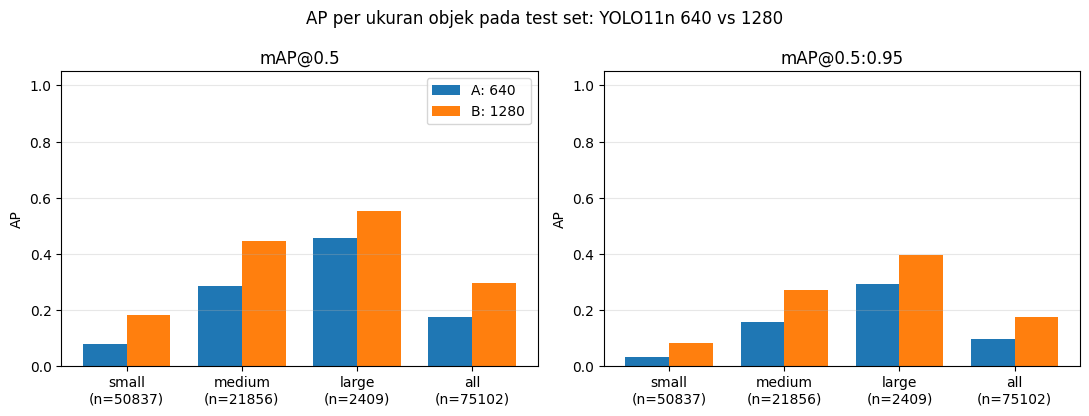

In [17]:
rows = []
for metric in ["mAP@0.5", "mAP@0.5:0.95", AR_KEY]:
    for size in AREA_RANGES:
        a, b = size_A.loc[size, metric], size_B.loc[size, metric]
        rows.append({"metric": metric, "size": size, "n_gt": int(n_gt[size]), "A_640": a, "B_1280": b,
                     "delta_abs": b - a, "delta_rel_%": (100 * (b - a) / a) if a and not np.isnan(a) else np.nan})
compare_df = pd.DataFrame(rows)
display(compare_df)
compare_df.to_csv(RESULTS_DIR / "size_specific_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sizes = ["small", "medium", "large", "all"]
x = np.arange(len(sizes)); w = 0.38
for ax, metric in zip(axes, ["mAP@0.5", "mAP@0.5:0.95"]):
    va = [size_A.loc[s, metric] for s in sizes]; vb = [size_B.loc[s, metric] for s in sizes]
    ax.bar(x - w/2, va, w, label=f"A: {IMGSZ_BASELINE}"); ax.bar(x + w/2, vb, w, label=f"B: {IMGSZ_INTERVENTION}")
    ax.set_xticks(x); ax.set_xticklabels([f"{s}\n(n={n_gt[s]})" for s in sizes])
    ax.set_ylim(0, 1.05); ax.set_title(metric); ax.set_ylabel("AP"); ax.grid(axis="y", alpha=.3)
axes[0].legend()
plt.suptitle("AP per ukuran objek pada test set: YOLO11n 640 vs 1280")
plt.tight_layout(); plt.savefig(FIG_DIR / "ap_by_size.png", dpi=200); plt.show()

# 6. Analisis kasus gagal
AP merangkum semua ambang skor. Di sini dipakai ambang tetap `CONF_VIS` dan `IOU_MATCH` untuk melihat objek mana yang terlewat. Contoh gambar kasus gagal diambil dari **kategori ukuran dengan jumlah FN terbanyak** (bukan kategori terkecil, karena kategori small bisa hampir kosong). GT dicocokkan greedy (skor tertinggi dulu):
- **Recall sadar-kelas:** kelas sama dan IoU >= IOU_MATCH.
- **Recall agnostik-kelas:** hanya IoU. Selisihnya menunjukkan kegagalan karena salah kelas (misalnya car vs van, pedestrian vs people), bukan lokalisasi.

In [18]:
def iou_matrix(a, b):
    """IoU antar himpunan kotak xyxy: a [N,4], b [M,4]."""
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    ix1 = np.maximum(a[:, None, 0], b[None, :, 0]); iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2]); iy2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (aa[:, None] + bb[None, :] - inter + 1e-9)

def match_image(gts, pred, conf_thr=CONF_VIS, iou_thr=IOU_MATCH, class_aware=True):
    """Pencocokan greedy. Return (gt_matched, kept_preds[(box,conf,cls)], pred_is_tp)."""
    xyxy, conf, cls = pred
    keep = np.where(conf >= conf_thr)[0]
    keep = keep[np.argsort(-conf[keep])]
    gt_boxes = np.array([g[1:] for g in gts], dtype=float).reshape(-1, 4)
    gt_cls = np.array([g[0] for g in gts])
    ious = iou_matrix(xyxy[keep], gt_boxes)
    gt_matched = [False] * len(gts); tp = []
    for row, k in enumerate(keep):
        cand = [j for j in range(len(gts))
                if not gt_matched[j] and ious[row, j] >= iou_thr and (not class_aware or gt_cls[j] == cls[k])]
        if cand:
            j = max(cand, key=lambda j: ious[row, j]); gt_matched[j] = True; tp.append(True)
        else:
            tp.append(False)
    return gt_matched, [(xyxy[k], conf[k], cls[k]) for k in keep], tp

gt_rows = []
for p in TEST_IMAGES:
    gts = gt_by_image[p]
    res = {tag: (match_image(gts, pred[p], class_aware=True)[0], match_image(gts, pred[p], class_aware=False)[0])
           for tag, pred in (("A", pred_A), ("B", pred_B))}
    for j, (cls, x1, y1, x2, y2) in enumerate(gts):
        area = (x2 - x1) * (y2 - y1)
        gt_rows.append({"image": p, "cls": cls, "area": area, "size": size_bucket(area),
                        "A_hit": res["A"][0][j], "A_hit_agn": res["A"][1][j],
                        "B_hit": res["B"][0][j], "B_hit_agn": res["B"][1][j]})
gt_df = pd.DataFrame(gt_rows)

rec_rows = []
for size in BUCKETS + ["All"]:
    sub = gt_df if size == "All" else gt_df[gt_df["size"] == size]
    if len(sub) == 0:
        continue
    rec_rows.append({"size": size, "n_gt": len(sub),
                     "recall_A_640": sub["A_hit"].mean(), "recall_B_1280": sub["B_hit"].mean(),
                     "recall_agnostik_A": sub["A_hit_agn"].mean(), "recall_agnostik_B": sub["B_hit_agn"].mean()})
recall_df = pd.DataFrame(rec_rows).set_index("size")
print(f"Recall pada conf>={CONF_VIS}, IoU>={IOU_MATCH}:")
display(recall_df)
recall_df.to_csv(RESULTS_DIR / "recall_by_size_at_conf.csv")

fp_rows = {}
for tag, pred in (("A_640", pred_A), ("B_1280", pred_B)):
    tp = fp = 0
    for p in TEST_IMAGES:
        _, _, flags = match_image(gt_by_image[p], pred[p])
        tp += sum(flags); fp += len(flags) - sum(flags)
    fp_rows[tag] = {"TP": tp, "FP": fp, "FN": len(gt_df) - int(gt_df[tag[0] + "_hit"].sum()),
                    "precision": tp / max(tp + fp, 1)}
fp_df = pd.DataFrame(fp_rows)
print(f"TP/FP/FN total pada conf>={CONF_VIS}:"); display(fp_df)
fp_df.to_csv(RESULTS_DIR / "tp_fp_fn_total.csv")

Recall pada conf>=0.25, IoU>=0.5:


,n_gt,recall_A_640,recall_B_1280,recall_agnostik_A,recall_agnostik_B
size,,,,,
Small,50837,0.1787,0.3377,0.2156,0.3923
Medium,21856,0.5928,0.7154,0.7004,0.8112
Large,2409,0.7443,0.8082,0.8294,0.8809
All,75102,0.3174,0.4627,0.3764,0.5299


TP/FP/FN total pada conf>=0.25:


,A_640,B_1280
TP,23835.0000,34748.0000
FP,17317.0000,21047.0000
FN,51267.0000,40354.0000
precision,0.5792,0.6228


Objek terlewat (FN) per ukuran pada conf>=0.25:


,n_gt,FN_A_640,FN_B_1280
Small,50837,41752,33671
Medium,21856,8899,6221
Large,2409,616,462


Fokus kasus gagal: objek Small (FN terbanyak)


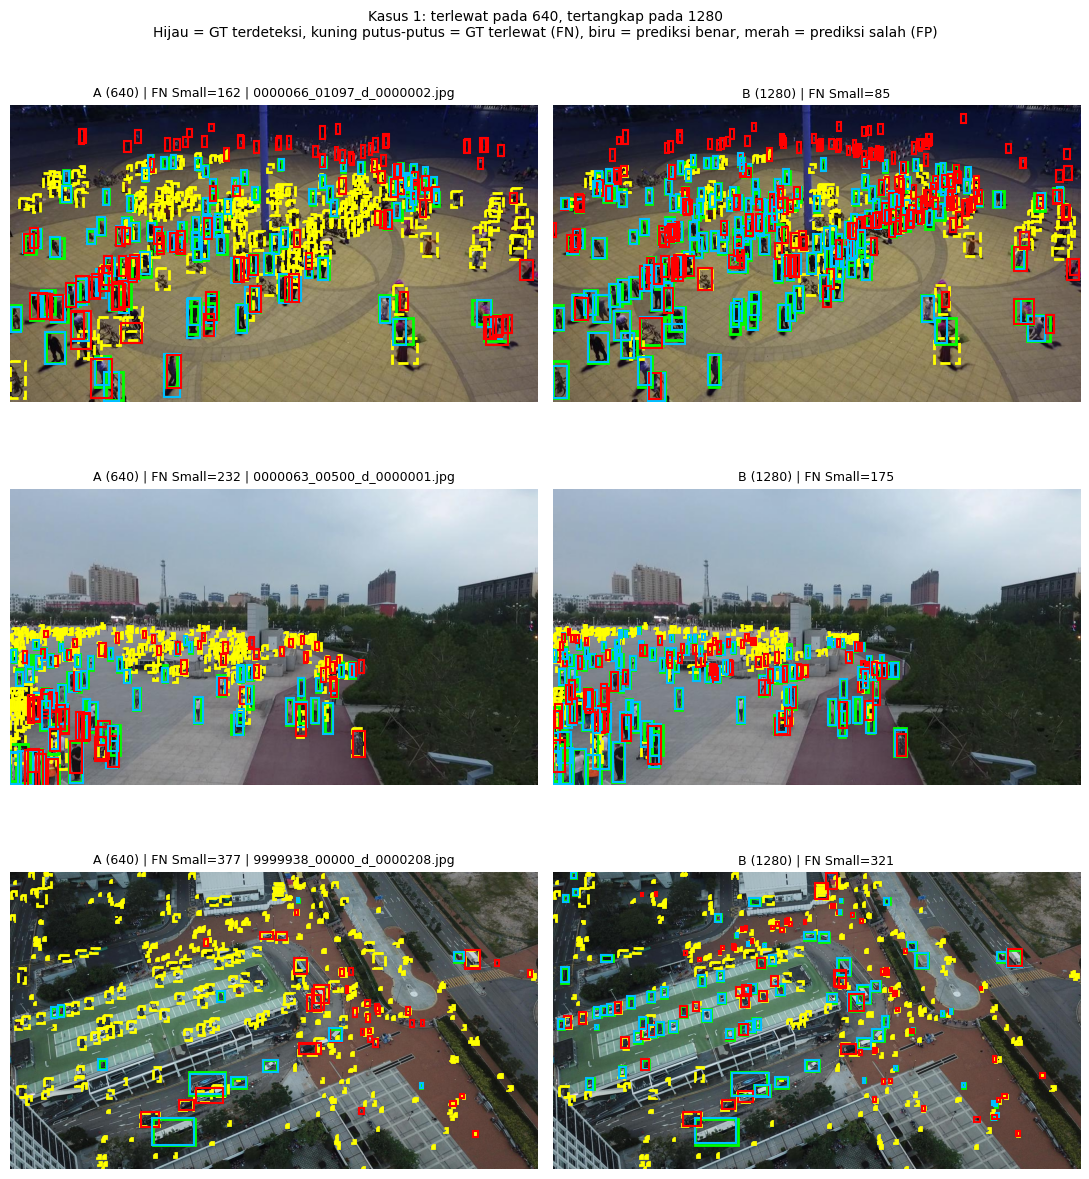

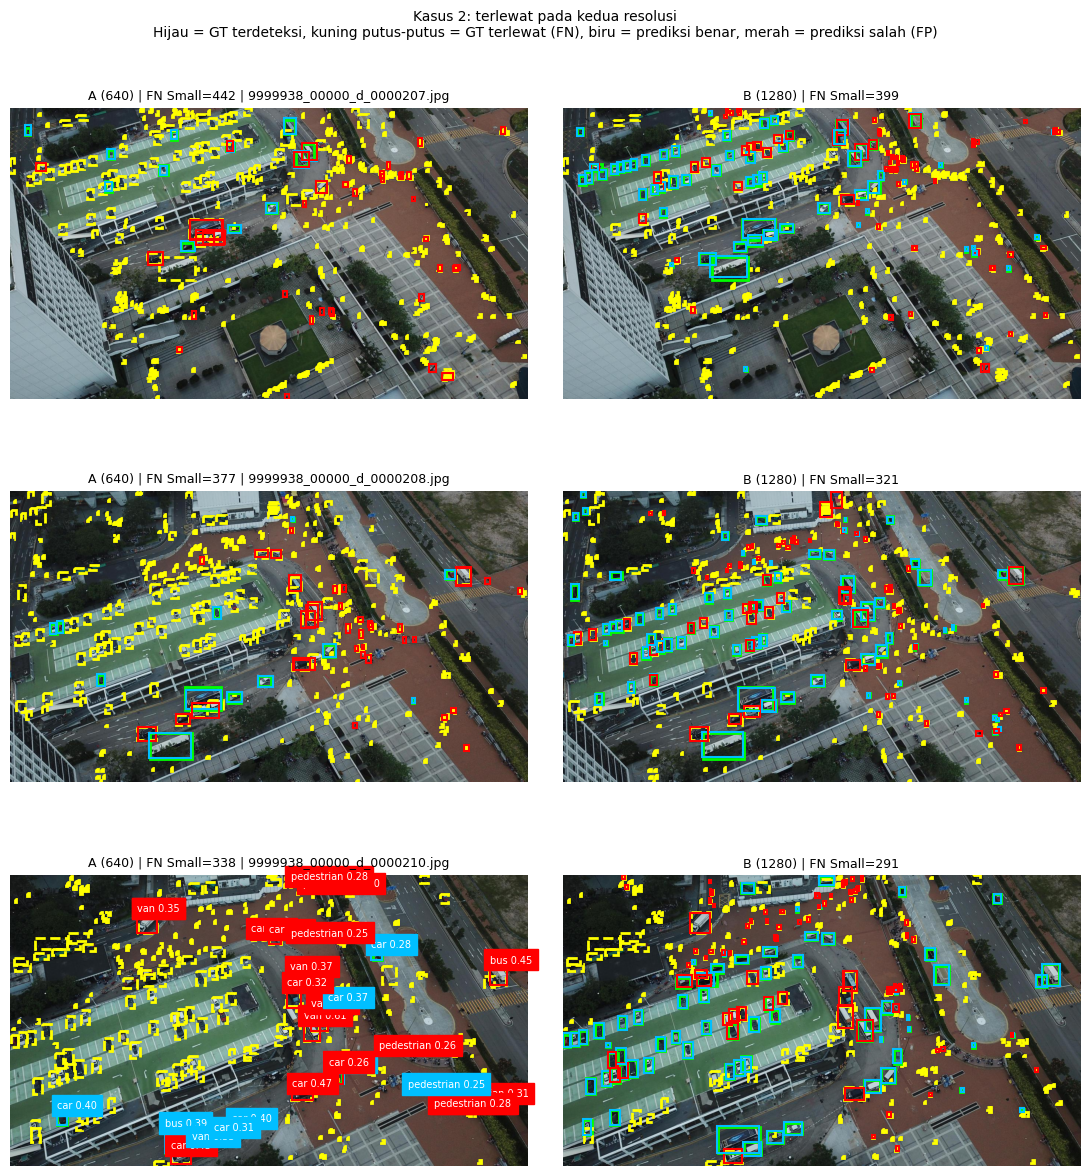

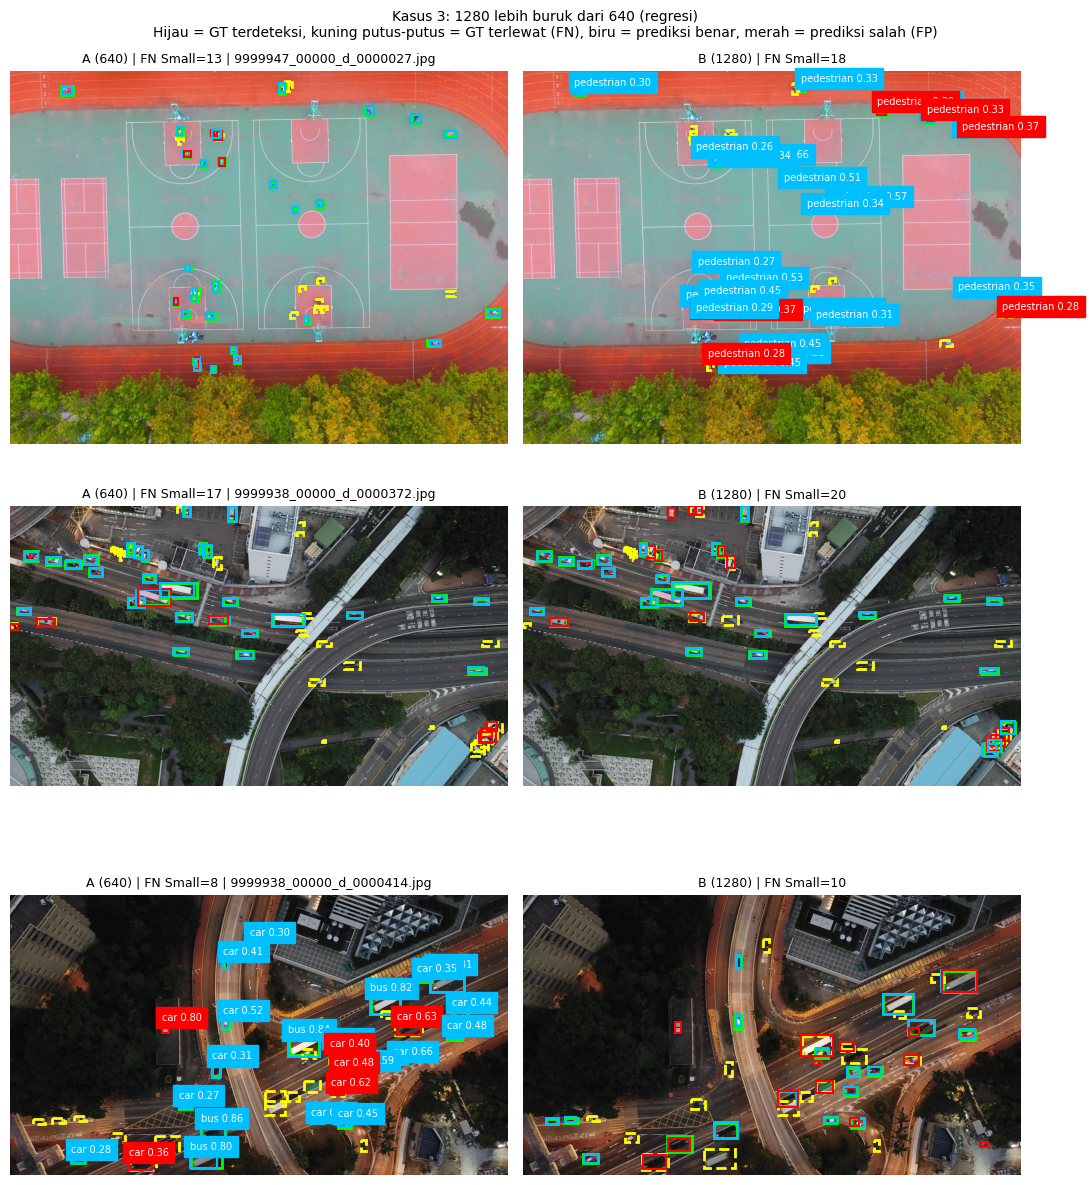

In [19]:
fn_rows = {}
for b in BUCKETS:
    sub = gt_df[gt_df["size"] == b]
    fn_rows[b] = {"n_gt": len(sub), "FN_A_640": int((~sub["A_hit"]).sum()), "FN_B_1280": int((~sub["B_hit"]).sum())}
fn_by_size = pd.DataFrame(fn_rows).T
print("Objek terlewat (FN) per ukuran pada conf>=%.2f:" % CONF_VIS)
display(fn_by_size)
fn_by_size.to_csv(RESULTS_DIR / "fn_by_size.csv")
# fokus = ukuran dengan total FN terbanyak (bukan sekadar ukuran terkecil yang ada)
focus = fn_by_size[["FN_A_640", "FN_B_1280"]].sum(axis=1).idxmax()
print(f"Fokus kasus gagal: objek {focus} (FN terbanyak)")
fn = gt_df[gt_df["size"] == focus].groupby("image").agg(
    fn_A=("A_hit", lambda s: int((~s).sum())), fn_B=("B_hit", lambda s: int((~s).sum())))
fn["fixed_by_B"] = fn["fn_A"] - fn["fn_B"]
fn["both_fail"] = np.minimum(fn["fn_A"], fn["fn_B"])

def draw_case(ax, path, pred, title):
    gts = gt_by_image[path]
    gt_m, kept, tp = match_image(gts, pred)
    ax.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
    for (cls, x1, y1, x2, y2), m in zip(gts, gt_m):
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2,
                                   ec="lime" if m else "yellow", ls="-" if m else "--"))
    for (b, c, k), ok in zip(kept, tp):
        ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, lw=1.5,
                                   ec="deepskyblue" if ok else "red"))
        if len(kept) <= 30:      # label hanya bila tidak terlalu padat
            ax.text(b[0], max(0, b[1] - 3), f"{CLASS_NAMES[k]} {c:.2f}", fontsize=7, color="white",
                    backgroundcolor="deepskyblue" if ok else "red")
    ax.set_title(title, fontsize=9); ax.axis("off")

def show_group(df_sorted, heading, fname, n=3):
    df_sorted = df_sorted.head(n)
    if df_sorted.empty:
        print(f"[{heading}] tidak ada kasus."); return
    fig, axes = plt.subplots(len(df_sorted), 2, figsize=(11, 4.2 * len(df_sorted)), squeeze=False)
    for i, (p, r) in enumerate(df_sorted.iterrows()):
        draw_case(axes[i, 0], p, pred_A[p], f"A ({IMGSZ_BASELINE}) | FN {focus}={int(r.fn_A)} | {os.path.basename(p)[:28]}")
        draw_case(axes[i, 1], p, pred_B[p], f"B ({IMGSZ_INTERVENTION}) | FN {focus}={int(r.fn_B)}")
    fig.suptitle(f"{heading}\nHijau = GT terdeteksi, kuning putus-putus = GT terlewat (FN), "
                 "biru = prediksi benar, merah = prediksi salah (FP)", fontsize=10)
    plt.tight_layout(); plt.savefig(FIG_DIR / fname, dpi=200); plt.show()

show_group(fn[fn["fixed_by_B"] > 0].sort_values("fixed_by_B", ascending=False),
           "Kasus 1: terlewat pada 640, tertangkap pada 1280", "failure_fixed_by_1280.png")
show_group(fn[fn["both_fail"] > 0].sort_values("both_fail", ascending=False),
           "Kasus 2: terlewat pada kedua resolusi", "failure_both.png")
show_group(fn[fn["fixed_by_B"] < 0].sort_values("fixed_by_B"),
           "Kasus 3: 1280 lebih buruk dari 640 (regresi)", "failure_regression_1280.png")
fn.to_csv(RESULTS_DIR / "failure_case_counts.csv")

# 7. Ringkasan, keterbatasan, dan penyimpanan hasil

In [20]:
summary = pd.DataFrame({
    "resolusi": [IMGSZ_BASELINE, IMGSZ_INTERVENTION],
    "epoch_dijalankan": [train_A["epochs_run"], train_B["epochs_run"]],
    "epoch_terbaik": [train_A["best_epoch"], train_B["best_epoch"]],
    "waktu_latih_menit": [train_A["train_minutes"], train_B["train_minutes"]],
    "params_M": [ultra_A["params_M"], ultra_B["params_M"]],
    "mAP@0.5_test": [ultra_A["mAP@0.5"], ultra_B["mAP@0.5"]],
    "mAP@0.5:0.95_test": [ultra_A["mAP@0.5:0.95"], ultra_B["mAP@0.5:0.95"]],
    "AP50_small": [size_A.loc["small", "mAP@0.5"], size_B.loc["small", "mAP@0.5"]],
    "AP50_medium": [size_A.loc["medium", "mAP@0.5"], size_B.loc["medium", "mAP@0.5"]],
    "AP50_large": [size_A.loc["large", "mAP@0.5"], size_B.loc["large", "mAP@0.5"]],
    "ms_per_citra": [ultra_A["total_ms_per_img"], ultra_B["total_ms_per_img"]],
    "FPS": [ultra_A["fps"], ultra_B["fps"]],
}, index=["A (baseline)", "B (intervensi)"]).T
display(summary)
summary.to_csv(RESULTS_DIR / "summary_table.csv")

save_json({"seed": SEED, "environment": env_info, "train_A": train_A, "train_B": train_B,
           "ultralytics_test_A": ultra_A, "ultralytics_test_B": ultra_B,
           "coco_size_A": size_A.to_dict(), "coco_size_B": size_B.to_dict(), "n_gt_test": n_gt}, "all_results.json")

print("\nFile hasil di", RESULTS_DIR)
for p in sorted(RESULTS_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(RESULTS_DIR))

,A (baseline),B (intervensi)
resolusi,640.0000,1280.0000
epoch_dijalankan,30.0000,30.0000
epoch_terbaik,30.0000,30.0000
waktu_latih_menit,27.3200,60.8800
params_M,2.5918,2.5918
mAP@0.5_test,0.2001,0.3249
mAP@0.5:0.95_test,0.1079,0.1869
AP50_small,0.0802,0.1808
AP50_medium,0.2847,0.4457
AP50_large,0.4546,0.5517



File hasil di /content/results
 - all_results.json
 - class_distribution.csv
 - dataset_split_summary.csv
 - environment.json
 - failure_case_counts.csv
 - figures/annotation_examples.png
 - figures/ap_by_size.png
 - figures/failure_both.png
 - figures/failure_fixed_by_1280.png
 - figures/failure_regression_1280.png
 - figures/size_distribution.png
 - fn_by_size.csv
 - grid_collision.csv
 - map50_crosscheck.csv
 - objects_per_image.csv
 - prediction_cache/model_A/0000006_00159_d_0000001.npz
 - prediction_cache/model_A/0000006_00611_d_0000002.npz
 - prediction_cache/model_A/0000006_01111_d_0000003.npz
 - prediction_cache/model_A/0000006_01275_d_0000004.npz
 - prediction_cache/model_A/0000006_01659_d_0000004.npz
 - prediction_cache/model_A/0000006_02138_d_0000006.npz
 - prediction_cache/model_A/0000006_02616_d_0000007.npz
 - prediction_cache/model_A/0000006_03636_d_0000009.npz
 - prediction_cache/model_A/0000006_04050_d_0000010.npz
 - prediction_cache/model_A/0000006_04309_d_0000011.npz

## Panduan menjawab pertanyaan riset (isi di laporan setelah melihat angka)
Tampilkan hasil apa adanya, termasuk bila tidak sesuai harapan.
1. **RQ1.** Bandingkan AP small vs medium vs large pada kondisi A. Rujuk `n_gt` sebelum menyimpulkan.
2. **RQ2.** Lihat delta_abs dan delta_rel_% AP small. Apakah selisihnya bermakna? Bandingkan dengan biaya (waktu latih, ms per citra, FPS).
3. **Sumber kegagalan.** Recall sadar-kelas vs agnostik-kelas: lokalisasi atau salah kelas?
4. **Kasus gagal.** Deskripsikan pola pada gambar Kasus 1-3.
5. **Klaim "berkelompok".** Hubungkan tabel bagian 3.2 (persen GT terbuang pada grid kasar) dengan hasil AP.

## Keterbatasan (verifikasi dengan output)
- Latih hanya sub-sampel (`TRAIN_SUBSET`) dari 6.471 citra karena batas waktu Colab, jadi angka mutlak lebih rendah dari model yang dilatih penuh.
- Satu seed dan satu run per kondisi. GPU tidak sepenuhnya deterministik. Selisih kecil bisa masuk rentang noise.
- Tanpa early stopping (`PATIENCE = 1000`) dan 30 epoch tetap: adil antar kondisi, tetapi kondisi 1280 mungkin belum konvergen dalam jumlah epoch yang sama.
- Ambang ukuran COCO memakai piksel citra asli. Ukuran citra VisDrone bervariasi, jadi "small" pada citra 1920x1080 tidak sama dengan pada citra 960x540.
- `MAX_DET = 500` (mengikuti praktik VisDrone; citra terpadat pada val punya sekitar 317 objek): citra yang lebih padat dari batas ini akan memotong recall.
- Kelas *ignored regions* dan *others* dibuang. Uji memakai test-dev (bukan test-challenge).
- Angka mAP@0,5 dari Ultralytics, pycocotools, dan AP manual bisa berbeda (bagian 5.2). Laporkan dengan jelas sumber tiap angka.
- Hanya YOLO11n.

## Saran pengembangan
Tiling/SAHI saat inferensi, beberapa seed, bootstrap atas citra untuk selang kepercayaan AP, latih pada seluruh 6.471 citra, model 11s/11m sebagai pembanding.